In [26]:
#1. Import Libraries
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
#Load Dataset
df = pd.read_csv("churn_data.csv")

print(df.head())
print(df.info())

  CustomerID  Tenure  MonthlyCharges  TotalCharges        Contract  \
0     C00001       6              64          1540        One year   
1     C00002      21             113          1753  Month-to-month   
2     C00003      27              31          1455        Two year   
3     C00004      53              29          7150  Month-to-month   
4     C00005      16             185          1023        One year   

      PaymentMethod PaperlessBilling  SeniorCitizen  Churn  
0       Credit Card               No              1      0  
1  Electronic Check              Yes              1      0  
2       Credit Card               No              1      0  
3  Electronic Check               No              1      0  
4  Electronic Check               No              1      0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID  

In [28]:
#Basic Cleaning
# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Convert TotalCharges to numeric
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')

# Handle missing values
df = df.dropna()

In [29]:
#Encode Target Variable
le = LabelEncoder()
df['churn'] = le.fit_transform(df['churn'])

In [30]:
#Encoding
#Label Encoding (Binary)
df['paperlessbilling'] = le.fit_transform(df['paperlessbilling'])

In [31]:
#One-Hot Encoding
df = pd.get_dummies(df, columns=['contract', 'paymentmethod'], drop_first=True)

In [32]:
#Manual Encoding
# SeniorCitizen is already 0/1, no need to encode


In [33]:
#Feature Scaling
#Standard Scaling
std_scaler = StandardScaler()
df['monthlycharges_std'] = std_scaler.fit_transform(df[['monthlycharges']])

In [34]:
#Min-Max Scaling
mm_scaler = MinMaxScaler()
df['monthlycharges_mm'] = mm_scaler.fit_transform(df[['monthlycharges']])

In [35]:
#Outlier Detection
#IQR Method
Q1 = df['monthlycharges'].quantile(0.25)
Q3 = df['monthlycharges'].quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = df[(df['monthlycharges'] < Q1 - 1.5*IQR) |
                  (df['monthlycharges'] > Q3 + 1.5*IQR)]

print("IQR Outliers:", len(outliers_iqr))

IQR Outliers: 0


In [36]:
#Z-score Method
z_scores = stats.zscore(df['monthlycharges'])
outliers_z = df[np.abs(z_scores) > 3]

print("Z-score Outliers:", len(outliers_z))

Z-score Outliers: 0


In [37]:
#Feature Engineering
# 1. Customer Lifetime Value
df['clv'] = df['monthlycharges'] * df['tenure']

# 2. Average Spend
df['avg_spend'] = df['totalcharges'] / (df['tenure'] + 1)

# 3. Payment Efficiency
df['payment_efficiency'] = df['totalcharges'] / (df['monthlycharges'] + 1)

# 4. Tenure Group
df['tenure_group'] = pd.cut(df['tenure'],
                           bins=[0,12,24,48,60],
                           labels=['new','mid','loyal','long'])

# 5. High Value Customer
df['high_value'] = (df['monthlycharges'] > df['monthlycharges'].median()).astype(int)

In [38]:
#Encode new categorical feature
df = pd.get_dummies(df, columns=['tenure_group'], drop_first=True)

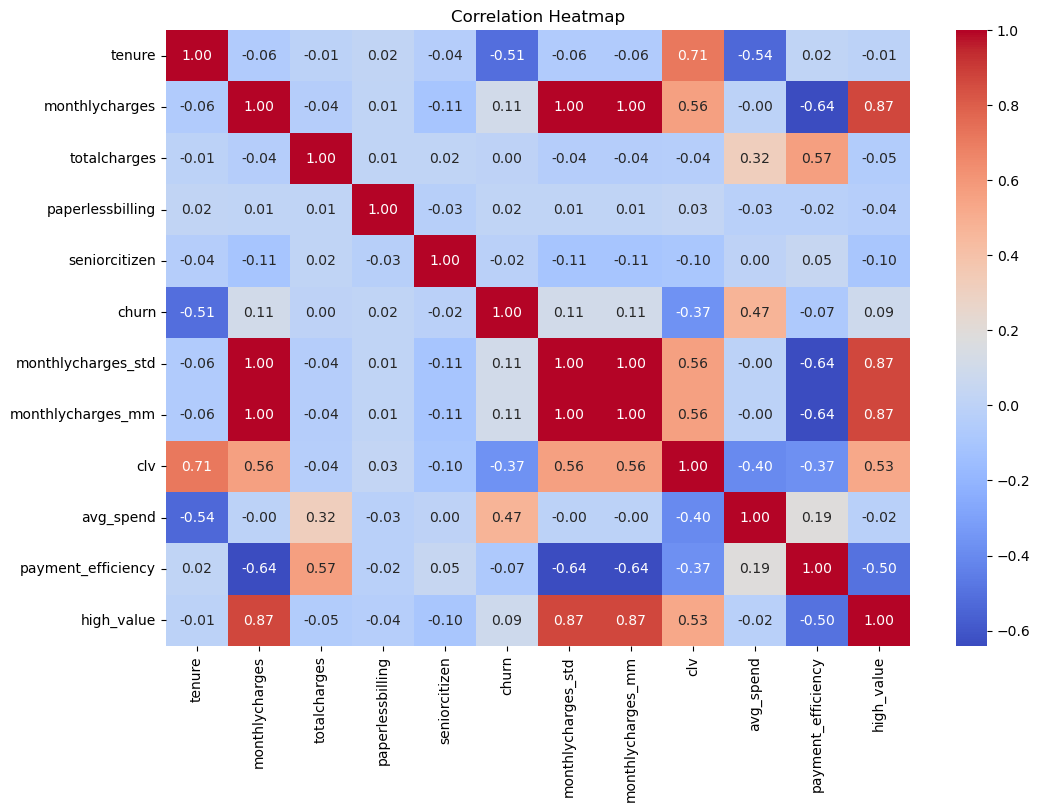

In [41]:

#Feature Selection
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,        # shows values
    fmt=".2f",
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [42]:
#Drop Irrelevant Columns
# Drop ID column
df = df.drop('customerid', axis=1)

In [43]:
#Define Features & Target
X = df.drop('churn', axis=1)
y = df['churn']

In [44]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [46]:
#Final Scaling
#Only scale numeric columns inside train-test split
num_cols = X_train.select_dtypes(include=[np.number]).columns

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [47]:
#Model Training
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [48]:
#Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [49]:
#Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.95
Precision: 0.8
Recall   : 0.7272727272727273
F1 Score : 0.7619047619047619


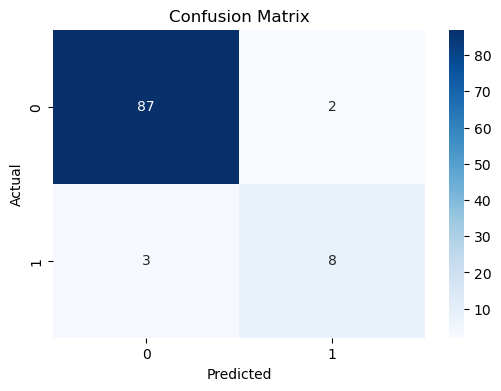

In [50]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

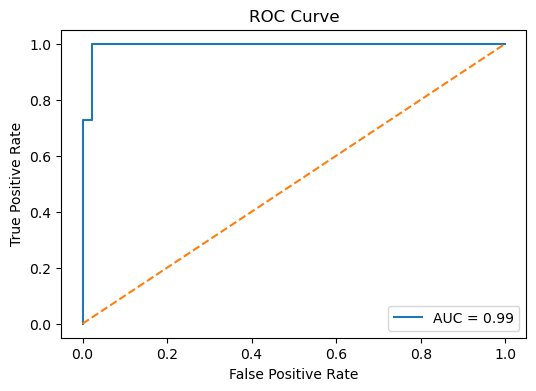

In [51]:
#ROC Curve
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


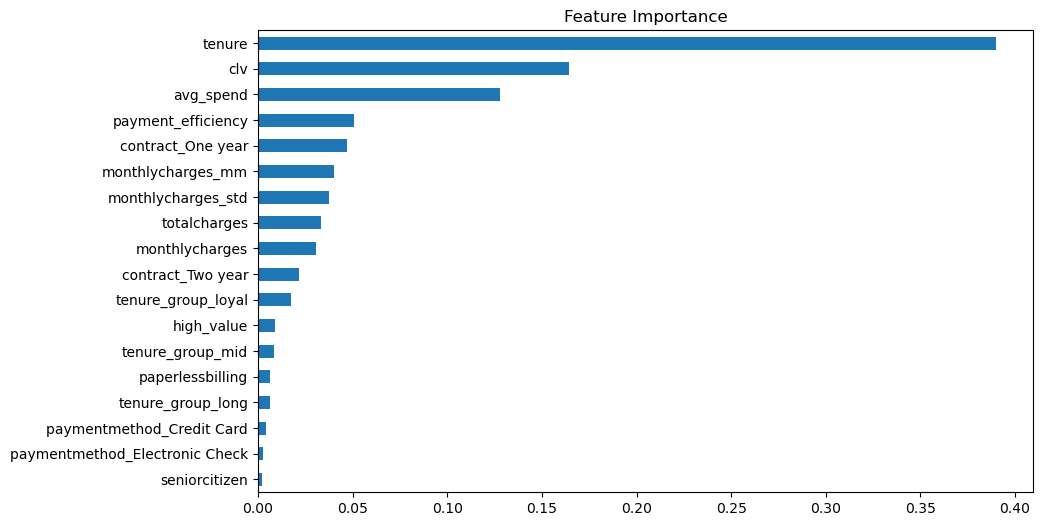

In [52]:
#Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns)

plt.figure(figsize=(10,6))
importances.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()